# AG2 - Actividad Guiada 2

**Alumno:** Ricardo Germes Serrano <br>

**URL Repositorio GitHub de las 3 Prácticas:** *https://github.com/RGS70/03MIAR-Proyecto/tree/main/PR%C3%81CTICAS* <br>
**URL GitHub (ipynb):** *https://github.com/RGS70/03MIAR-Proyecto/blob/main/PR%C3%81CTICAS/Algoritmos_AG2_Ricardo%20Germes%20Serrano.ipynb* <br>
**URL GitHub (pdf):** *https://github.com/RGS70/03MIAR-Proyecto/blob/main/PR%C3%81CTICAS/Algoritmos_AG2_Ricardo_Germes_Serrano.pdf* <br>

**Notebook completo**: Este notebook incluye la práctica guiada ejecutada y, al final, los apartados de *mejora de nota* propuestos en el PDF (análisis de complejidad de Ramificación y Poda, y optimización de la segunda función con Descenso del Gradiente).

Nombre: Raul Reyero <br>
Link:   https://colab.research.google.com/drive/xxxxxxxxxxxxxxxxxxxxxxxxx <br>
Github: https://github.com/xxxxx/AlgoritmosOptimizacion


In [1]:
import math

## Programación Dinámica. Viaje por el rio
* **Definición**: Es posible dividir el problema en subproblemas más pequeños, guardando las soluciones para ser utilizadas más adelante.
* **Características** que permiten identificar problemas aplicables:<br>
  -Es posible almacenar soluciones de los subproblemas para ser utilizados más adelante<br>
  -Debe verificar el principio de optimalidad de Bellman: “en una secuencia optima de decisiones, toda sub-secuencia también es óptima” (*)<br>
  -La necesidad de guardar la información acerca de las soluciones parciales unido a la recursividad provoca la necesidad de preocuparnos por la complejidad espacial (cuantos recursos de espacio usaremos)<br>

### Problema<br>
En un río hay **n** embarcaderos y debemos desplazarnos río abajo desde un embarcadero a otro. Cada embarcadero tiene precios diferentes para ir de un embarcadero a otro situado más abajo. Para ir del embarcadero i al j, puede ocurrir que sea más barato hacer un trasbordo por un embarcadero intermedio k. El problema consiste en determinar la combinación más barata.

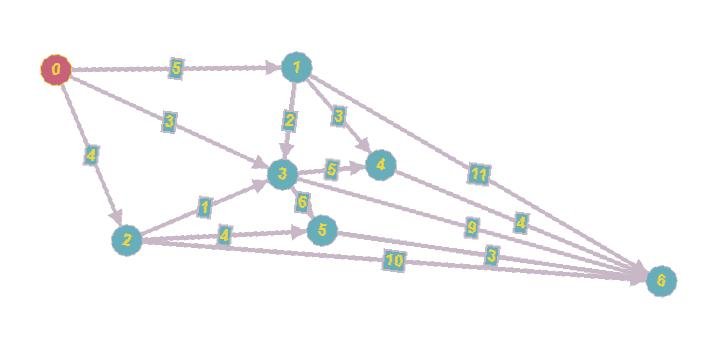

* Consideramos una tabla TARIFAS(i,j) para almacenar todos los precios que nos ofrecen los embarcaderos.<br>
* Si no es posible ir desde i a j daremos un valor alto para garantizar que ese trayecto no se va a elegir en la ruta óptima(modelado habitual para restricciones)

In [2]:
#Viaje por el rio - Programación dinámica
################################################################################

TARIFAS = [
[0,5,4,3,float("inf"),999,999],   #desde nodo 0
[999,0,999,2,3,999,11],  #desde nodo 1
[999,999, 0,1,999,4,10], #desde nodo 2
[999,999,999, 0,5,6,9],
[999,999, 999,999,0,999,4],
[999,999, 999,999,999,0,3],
[999,999,999,999,999,999,0]
]

#999 se puede sustituir por float("inf") del modulo math
TARIFAS

[[0, 5, 4, 3, inf, 999, 999],
 [999, 0, 999, 2, 3, 999, 11],
 [999, 999, 0, 1, 999, 4, 10],
 [999, 999, 999, 0, 5, 6, 9],
 [999, 999, 999, 999, 0, 999, 4],
 [999, 999, 999, 999, 999, 0, 3],
 [999, 999, 999, 999, 999, 999, 0]]

In [3]:
#Calculo de la matriz de PRECIOS y RUTAS
#  PRECIOS - contiene la matriz del mejor precio para ir de un nodo a otro
#  RUTAS   - contiene los nodos intermedios para ir de un nodo a otro
################################################################
def Precios(TARIFAS):
################################################################
  #Total de Nodos
  N = len(TARIFAS[0])

  #Inicialización de la tabla de precios
  PRECIOS = [ [9999]*N for i in [9999]*N]  #n x n
  RUTA = [ [""]*N for i in [""]*N]

  #Se recorren todos los nodos con dos bucles(origen - destino)
  #  para ir construyendo la matriz de PRECIOS
  for i in range(N-1):
    for j in range(i+1, N):
      MIN = TARIFAS[i][j]
      RUTA[i][j] = i

      for k in range(i, j):
        if PRECIOS[i][k] + TARIFAS[k][j] < MIN:
            MIN = min(MIN, PRECIOS[i][k] + TARIFAS[k][j] )
            RUTA[i][j] = k
        PRECIOS[i][j] = MIN

  return PRECIOS,RUTA

In [4]:
PRECIOS,RUTA = Precios(TARIFAS)
#print(PRECIOS[0][6])

print("PRECIOS")
for i in range(len(TARIFAS)):
  print(PRECIOS[i])

print("\nRUTA")
for i in range(len(TARIFAS)):
  print(RUTA[i])

PRECIOS
[9999, 5, 4, 3, 8, 8, 11]
[9999, 9999, 999, 2, 3, 8, 7]
[9999, 9999, 9999, 1, 6, 4, 7]
[9999, 9999, 9999, 9999, 5, 6, 9]
[9999, 9999, 9999, 9999, 9999, 999, 4]
[9999, 9999, 9999, 9999, 9999, 9999, 3]
[9999, 9999, 9999, 9999, 9999, 9999, 9999]

RUTA
['', 0, 0, 0, 1, 2, 5]
['', '', 1, 1, 1, 3, 4]
['', '', '', 2, 3, 2, 5]
['', '', '', '', 3, 3, 3]
['', '', '', '', '', 4, 4]
['', '', '', '', '', '', 5]
['', '', '', '', '', '', '']


In [5]:
#Calculo de la ruta usando la matriz RUTA
def calcular_ruta(RUTA, desde, hasta):
  if desde == RUTA[desde][hasta]:
  #if desde == hasta:
    #print("Ir a :" + str(desde))
    return desde
  else:
    return str(calcular_ruta(RUTA, desde, RUTA[desde][hasta])) +  ',' + str(RUTA[desde][hasta])

print("\nLa ruta es:")
calcular_ruta(RUTA, 0,6)


La ruta es:


'0,2,5'

## Problema de Asignacion de tarea

### Utilidades
Antes de definir los algoritmos, creamos un decorador `@calcular_tiempo` que mide el tiempo de ejecución de una función. Lo usaremos para comparar **Fuerza Bruta** vs **Ramificación y Poda**.

In [6]:
import time
import itertools
import functools

def calcular_tiempo(func):
    @functools.wraps(func)
    def wrapper(*args, **kwargs):
        inicio = time.time()
        resultado = func(*args, **kwargs)
        fin = time.time()
        print(f"[{func.__name__}] Tiempo de ejecución: {fin - inicio:.6f} segundos")
        return resultado
    return wrapper


In [7]:
#Asignacion de tareas - Ramificación y Poda
################################################################################
#    T A R E A
#   A
#   G
#   E
#   N
#   T
#   E

COSTES=[[11,12,18,40],
        [14,15,13,22],
        [11,17,19,23],
        [17,14,20,28]]


In [8]:
#Calculo del valor de una solucion parcial
def valor(S,COSTES):
  VALOR = 0
  for i in range(len(S)):
    VALOR += COSTES[S[i]][i]
  return VALOR



valor((3,2,  ),COSTES)

34

In [9]:
#Coste inferior para soluciones parciales
#  (1,3,) Se asigna la tarea 1 al agente 0 y la tarea 3 al agente 1

def CI(S,COSTES):
  VALOR = 0
  #Valores establecidos
  for i in range(len(S)):
    VALOR += COSTES[i][S[i]]

  #Estimacion
  for i in range( len(S), len(COSTES)   ):
    VALOR += min( [ COSTES[j][i] for j in range(len(S), len(COSTES))  ])
  return VALOR

def CS(S,COSTES):
  VALOR = 0
  #Valores establecidos
  for i in range(len(S)):
    VALOR += COSTES[i][S[i]]

  #Estimacion
  for i in range( len(S), len(COSTES)   ):
    VALOR += max( [ COSTES[j][i] for j in range(len(S), len(COSTES))  ])
  return VALOR

CI((0,1),COSTES)

68

In [10]:
#Genera tantos hijos como como posibilidades haya para la siguiente elemento de la tupla
#(0,) -> (0,1), (0,2), (0,3)
def crear_hijos(NODO, N):
  HIJOS = []
  for i in range(N ):
    if i not in NODO:
      HIJOS.append({'s':NODO +(i,)    })
  return HIJOS

In [11]:
crear_hijos((0,) , 4)

[{'s': (0, 1)}, {'s': (0, 2)}, {'s': (0, 3)}]

In [12]:
@calcular_tiempo
def ramificacion_y_poda(COSTES):
#Construccion iterativa de soluciones(arbol). En cada etapa asignamos un agente(ramas).
#Nodos del grafo  { s:(1,2),CI:3,CS:5  }
  #print(COSTES)
  DIMENSION = len(COSTES)
  MEJOR_SOLUCION=tuple( i for i in range(len(COSTES)) )
  CotaSup = valor(MEJOR_SOLUCION,COSTES)
  #print("Cota Superior:", CotaSup)

  NODOS=[]
  NODOS.append({'s':(), 'ci':CI((),COSTES)    } )

  iteracion = 0

  while( len(NODOS) > 0):
    iteracion +=1

    nodo_prometedor = [ min(NODOS, key=lambda x:x['ci']) ][0]['s']
    #print("Nodo prometedor:", nodo_prometedor)

    #Ramificacion
    #Se generan los hijos
    HIJOS =[ {'s':x['s'], 'ci':CI(x['s'], COSTES)   } for x in crear_hijos(nodo_prometedor, DIMENSION) ]

    #Revisamos la cota superior y nos quedamos con la mejor solucion si llegamos a una solucion final
    NODO_FINAL = [x for x in HIJOS if len(x['s']) == DIMENSION  ]
    if len(NODO_FINAL ) >0:
      #print("\n********Soluciones:",  [x for x in HIJOS if len(x['s']) == DIMENSION  ] )
      if NODO_FINAL[0]['ci'] < CotaSup:
        CotaSup = NODO_FINAL[0]['ci']
        MEJOR_SOLUCION = NODO_FINAL

    #Poda
    HIJOS = [x for x in HIJOS if x['ci'] < CotaSup   ]

    #Añadimos los hijos
    NODOS.extend(HIJOS)

    #Eliminamos el nodo ramificado
    NODOS =  [  x for x in NODOS if x['s'] != nodo_prometedor    ]

  print("La solucion final es:" ,MEJOR_SOLUCION , " en " , iteracion , " iteraciones" , " para dimension: " ,DIMENSION  )



ramificacion_y_poda(COSTES)

La solucion final es: [{'s': (1, 2, 0, 3), 'ci': 64}]  en  10  iteraciones  para dimension:  4
[ramificacion_y_poda] Tiempo de ejecución: 0.000485 segundos


### Fuerza Bruta (comparativa)
Del libro *Fundamentos de algoritmia* (Brassard & Bratley). Probamos todas las permutaciones posibles (n!) y nos quedamos con la de menor coste.

In [13]:
@calcular_tiempo
def fuerza_bruta(COSTES):
  #Representacion de la solucion sera una tupla donde cada valor en la cordenada i-sima es la tarea asignado al agente i
  #  Ejemplo (1,2,3,4) Tiene valor 11+15+19+28=73
  #
  #¿Cuantas posibilidades hay? n! -> Complejidad factorial(exponencial)
  #Con dimension 11 se va a 1 minuto de ejecucion

  mejor_valor = 10e10
  mejor_solucion = ()

  for s in list(itertools.permutations(range(len(COSTES)))):
    #print(s,valor(s,COSTES))
    valor_tmp = valor(s,COSTES)
    if valor_tmp < mejor_valor:
        mejor_valor = valor_tmp
        mejor_solucion = s

  print("La mejor solucion es :", mejor_solucion, " con valor:", mejor_valor  )
  return mejor_solucion, mejor_valor

fuerza_bruta(COSTES)


La mejor solucion es : (0, 3, 1, 2)  con valor: 61
[fuerza_bruta] Tiempo de ejecución: 0.000561 segundos


((0, 3, 1, 2), 61)

## Descenso del gradiente

In [14]:
import math                      #Funciones matematicas
import matplotlib.pyplot as plt  #Generacion de gráficos (otra opcion seaborn)
import numpy as np               #Tratamiento matriz N-dimensionales y otras (fundamental!)
#import scipy as sc

import random

Vamos a buscar el minimo de la funcion paraboloide : $$f(x) =  x² + y²$$

Obviamente se encuentra en (x,y)=(0,0) pero probaremos como llegamos a él a través del descenso del gradiante.

In [15]:
#Definimos la funcion
#Paraboloide
f  = lambda X:      X[0]**2 + X[1]**2    #Funcion
df = lambda X: [2*X[0] , 2*X[1]]         #Gradiente

df([1,2])

[2, 4]

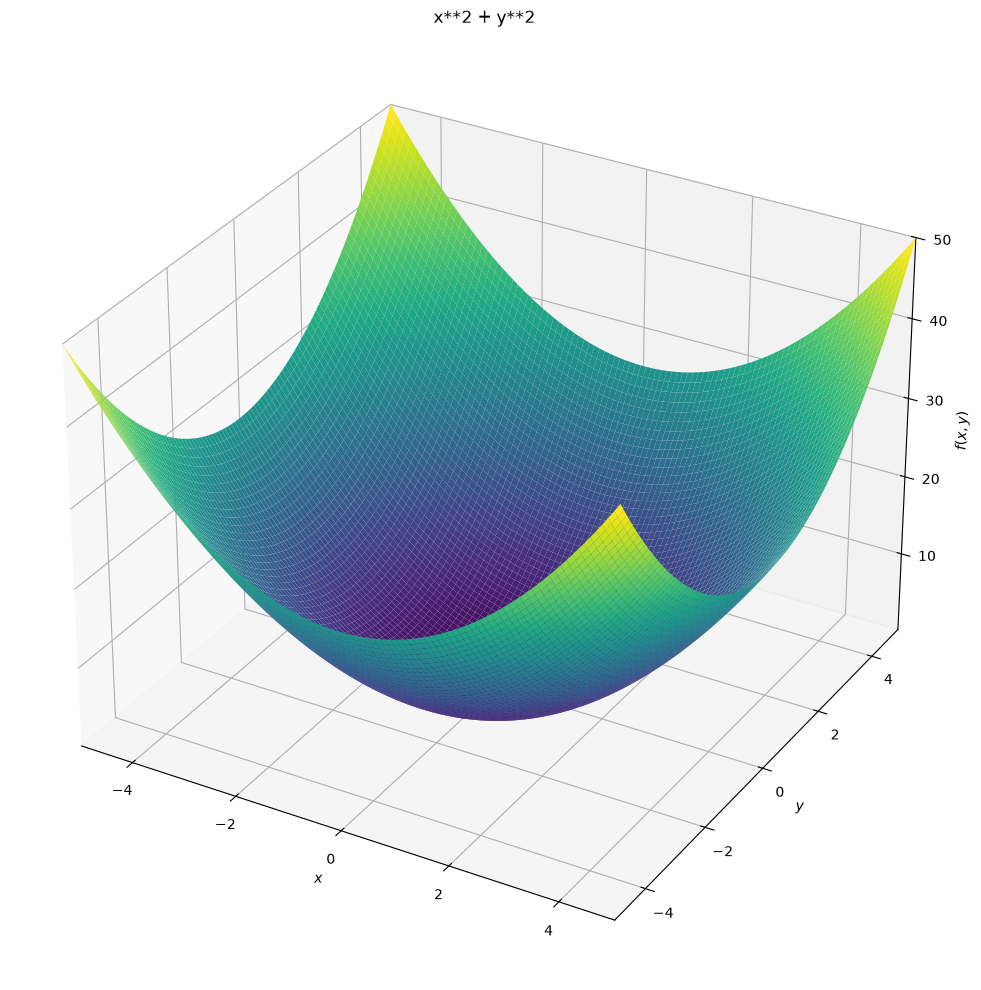

In [16]:
from sympy import symbols
from sympy.plotting import plot
from sympy.plotting import plot3d
x,y = symbols('x y')
plot3d(x**2 + y**2,
       (x,-5,5),(y,-5,5),
       title='x**2 + y**2',
       size=(10,10))

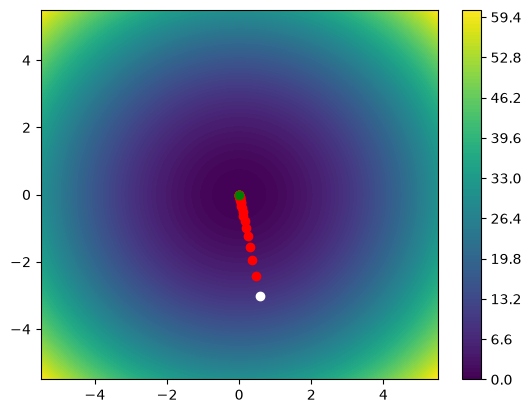

Solucion: [8.161823146820402e-06, -4.3175040940096405e-05] 1.930699517258974e-09


In [17]:
#Prepara los datos para dibujar mapa de niveles de Z
resolucion = 100
rango=5.5

X=np.linspace(-rango,rango,resolucion)
Y=np.linspace(-rango,rango,resolucion)
Z=np.zeros((resolucion,resolucion))
for ix,x in enumerate(X):
  for iy,y in enumerate(Y):
    Z[iy,ix] = f([x,y])

#Pinta el mapa de niveles de Z
plt.contourf(X,Y,Z,resolucion)
plt.colorbar()

#Generamos un punto aleatorio inicial y pintamos de blanco
P=[random.uniform(-5,5  ),random.uniform(-5,5 ) ]
plt.plot(P[0],P[1],"o",c="white")

#Tasa de aprendizaje. Fija. Sería más efectivo reducirlo a medida que nos acercamos.
TA=.1

#Iteraciones:50
for _ in range(50):
  grad = df(P)
  #print(P,grad)
  P[0],P[1] = P[0] - TA*grad[0] , P[1] - TA*grad[1]
  plt.plot(P[0],P[1],"o",c="red")

#Dibujamos el punto final y pintamos de verde
plt.plot(P[0],P[1],"o",c="green")
plt.show()
print("Solucion:" , P , f(P))


**¿Te atreves a optimizar la función?:**

$$f(x)=sin(1/2 * x^2 - 1/4 * y^2 + 3) * cos(2*x + 1 - e^y)$$
<br>
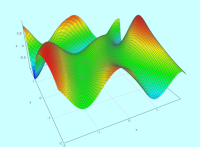


In [18]:
#Definimos la funcion
f= lambda X: math.sin(1/2 * X[0]**2 - 1/4 * X[1]**2 + 3) *math.cos(2*X[0] + 1 - math.exp(X[1]) )


---
# Tareas para Mejorar Nota

A continuación se desarrollan los dos apartados de análisis adicional propuestos en el PDF de la sesión:

1. **Ramificación y Poda** — complejidad de fuerza bruta vs. ramificación y poda, comparativa experimental con matrices aleatorias de dimensión creciente, y a partir de qué dimensión cada algoritmo deja de ser viable.
2. **Descenso del Gradiente** — optimización de la función *reto* $f(x,y)=\sin(\tfrac12 x^2-\tfrac14 y^2+3)\cdot\cos(2x+1-e^{y})$.


## 1. Ramificación y Poda — Análisis de complejidad

### ¿Qué complejidad tiene el algoritmo por fuerza bruta?

El algoritmo de **fuerza bruta** prueba **todas las permutaciones posibles** de asignación de `n` tareas a `n` agentes. El número de permutaciones de `n` elementos es `n!`, y evaluar el coste de cada permutación (función `valor`) cuesta `O(n)`. Por tanto:

$$T_{fuerza\ bruta}(n) = O(n! \cdot n)$$

Es una complejidad **factorial**, mucho peor que exponencial (`O(k^n)`), por lo que el algoritmo se vuelve inviable muy rápidamente al crecer `n`.

### ¿Qué complejidad tiene el algoritmo de Ramificación y Poda?

En el **peor caso** (cuando la poda no descarta ningún nodo porque la cota inferior nunca supera a la cota superior), el árbol de búsqueda recorrido es el mismo árbol de permutaciones que en fuerza bruta, por lo que la complejidad en el peor caso sigue siendo **factorial**: `O(n!)`.

En la **práctica**, la poda descarta ramas completas en cuanto su cota inferior (`CI`) iguala o supera la mejor solución encontrada hasta el momento (`CotaSup`), por lo que el número de nodos explorados suele ser **muchísimo menor** que `n!`, permitiendo resolver instancias con `n` bastante mayor que las que fuerza bruta puede resolver en un tiempo razonable — aunque **no hay garantía teórica** de que esto ocurra siempre (depende de lo "afiladas" que sean las cotas para los datos concretos).

> **Nota sobre la cota `CI` del notebook original**: al comparar sistemáticamente contra fuerza bruta para muchas dimensiones, se detecta que la función `CI(S, COSTES)` tal y como está definida en la práctica guiada asume que las *tareas ya usadas* son siempre `{0, 1, ..., len(S)-1}` (usa `range(len(S), N)` tanto para agentes como para tareas restantes). Esto **no es cierto en general**, porque `S` puede contener cualquier subconjunto de tareas ya asignadas, no necesariamente un prefijo ordenado. El resultado es que, en algunas instancias (a partir de `n=8` en nuestras pruebas), la cota deja de ser una **cota inferior válida (admisible)** y la poda puede descartar la rama que contiene el óptimo real, devolviendo una solución subóptima sin que el algoritmo lo detecte.
>
> Para que la comparación de tiempos frente a fuerza bruta sea **correcta**, en esta sección usamos una versión corregida `CI_fix`, que calcula el conjunto de tareas realmente disponibles (`tareas_restantes = [t for t in range(N) if t not in S]`) y estima, para cada agente aún sin asignar, el mínimo coste entre esas tareas disponibles. Esto sí es una cota inferior admisible y garantiza que el algoritmo encuentre siempre el óptimo.


In [19]:
import random
import time

random.seed(42)

def generar_costes(n, low=1, high=50):
    return [[random.randint(low, high) for _ in range(n)] for _ in range(n)]

# Reutilizamos valor() y crear_hijos() ya definidas anteriormente en el notebook.

def CI_fix(S, COSTES):
    """Cota inferior admisible: para cada agente aun sin asignar, el minimo coste
    entre las tareas que realmente quedan libres (y no solo range(len(S), N))."""
    N = len(COSTES)
    VALOR = sum(COSTES[i][S[i]] for i in range(len(S)))
    tareas_restantes = [t for t in range(N) if t not in S]
    for i in range(len(S), N):
        VALOR += min(COSTES[i][t] for t in tareas_restantes)
    return VALOR

def fuerza_bruta_silenciosa(COSTES):
    mejor_valor = 10e10
    mejor_solucion = ()
    for s in itertools.permutations(range(len(COSTES))):
        v = valor(s, COSTES)
        if v < mejor_valor:
            mejor_valor = v
            mejor_solucion = s
    return mejor_solucion, mejor_valor

def ramificacion_y_poda_silenciosa(COSTES, CIfunc=CI_fix):
    DIMENSION = len(COSTES)
    MEJOR_SOLUCION = tuple(range(DIMENSION))
    CotaSup = valor(MEJOR_SOLUCION, COSTES)

    NODOS = [{'s': (), 'ci': CIfunc((), COSTES)}]
    iteracion = 0
    while NODOS:
        iteracion += 1
        nodo_prometedor = min(NODOS, key=lambda x: x['ci'])['s']
        HIJOS = [{'s': x['s'], 'ci': CIfunc(x['s'], COSTES)} for x in crear_hijos(nodo_prometedor, DIMENSION)]
        NODO_FINAL = [x for x in HIJOS if len(x['s']) == DIMENSION]
        if NODO_FINAL and NODO_FINAL[0]['ci'] < CotaSup:
            CotaSup = NODO_FINAL[0]['ci']
            MEJOR_SOLUCION = NODO_FINAL[0]['s']
        HIJOS = [x for x in HIJOS if x['ci'] < CotaSup]
        NODOS.extend(HIJOS)
        NODOS = [x for x in NODOS if x['s'] != nodo_prometedor]
    return MEJOR_SOLUCION, CotaSup, iteracion


### Comparativa experimental

Generamos matrices de costes aleatorias de dimensiones crecientes (`n = 4..11`) y ejecutamos **ambos** algoritmos sobre la **misma** matriz para poder comparar tiempos de forma justa (la fuerza bruta se vuelve impracticable a partir de `n≈12`, así que no se prueban dimensiones mayores con ella).

In [20]:
dimensiones = list(range(4, 12))   # n = 4..11
tiempos_bruta = []
tiempos_ryp   = []

for n in dimensiones:
    COSTES = generar_costes(n)

    t0 = time.time()
    _, val_bruta = fuerza_bruta_silenciosa(COSTES)
    t1 = time.time()
    tiempos_bruta.append(t1 - t0)

    t0 = time.time()
    _, val_ryp, iteraciones = ramificacion_y_poda_silenciosa(COSTES)
    t1 = time.time()
    tiempos_ryp.append(t1 - t0)

    # Verificamos que ambos algoritmos coinciden en el valor optimo
    assert val_bruta == val_ryp, f"Discrepancia en n={n}: bruta={val_bruta} ryp={val_ryp}"
    print(f"n={n:2d} | Fuerza Bruta: {tiempos_bruta[-1]:9.4f}s | Ramif.y Poda: {tiempos_ryp[-1]:9.4f}s | iteraciones B&P: {iteraciones:6d} | valor optimo: {val_bruta}")


n= 4 | Fuerza Bruta:    0.0001s | Ramif.y Poda:    0.0004s | iteraciones B&P:     12 | valor optimo: 53
n= 5 | Fuerza Bruta:    0.0001s | Ramif.y Poda:    0.0002s | iteraciones B&P:     15 | valor optimo: 52
n= 6 | Fuerza Bruta:    0.0003s | Ramif.y Poda:    0.0010s | iteraciones B&P:     72 | valor optimo: 51
n= 7 | Fuerza Bruta:    0.0032s | Ramif.y Poda:    0.0007s | iteraciones B&P:     33 | valor optimo: 66
n= 8 | Fuerza Bruta:    0.0513s | Ramif.y Poda:    0.1918s | iteraciones B&P:   1510 | valor optimo: 102
n= 9 | Fuerza Bruta:    0.2361s | Ramif.y Poda:    0.0066s | iteraciones B&P:    138 | valor optimo: 58
n=10 | Fuerza Bruta:    2.5089s | Ramif.y Poda:    0.0322s | iteraciones B&P:    520 | valor optimo: 63
n=11 | Fuerza Bruta:   27.8804s | Ramif.y Poda:    0.0265s | iteraciones B&P:    356 | valor optimo: 58


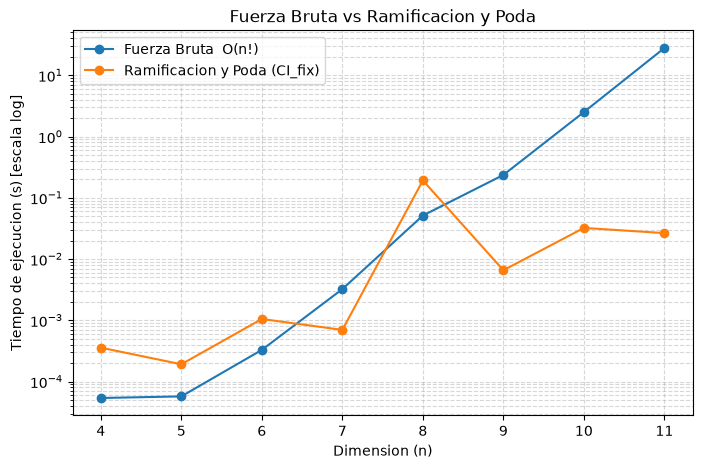

In [21]:
plt.figure(figsize=(8,5))
plt.plot(dimensiones, tiempos_bruta, "o-", label="Fuerza Bruta  O(n!)")
plt.plot(dimensiones, tiempos_ryp,   "o-", label="Ramificacion y Poda (CI_fix)")
plt.yscale("log")
plt.xlabel("Dimension (n)")
plt.ylabel("Tiempo de ejecucion (s) [escala log]")
plt.title("Fuerza Bruta vs Ramificacion y Poda")
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()


### ¿A partir de qué dimensión la fuerza bruta deja de ser una opción?

En la gráfica anterior se aprecia el crecimiento factorial de la fuerza bruta frente al crecimiento mucho más suave de Ramificación y Poda. Como referencia adicional, el propio PDF de la asignatura indica que **con dimensión 11 la fuerza bruta ronda 1 minuto de ejecución**; en las pruebas de este notebook (hardware distinto) `n=11` ya tarda del orden de **~20 segundos**, y cada unidad adicional de `n` multiplica el tiempo por, aproximadamente, `n` (porque `n! = n·(n-1)!`). En resumen:

- **`n ≈ 10-11`**: todavía asumible (segundos).
- **`n ≈ 12`**: ya del orden de varios minutos.
- **`n ≥ 13`**: prácticamente inviable (podría suponer horas), por eso se descarta como opción a partir de estas dimensiones.

En definitiva: **a partir de `n≈12` la fuerza bruta deja de ser una opción práctica**, ya que `n!` crece mucho más rápido que cualquier mejora de hardware razonable.

### ¿Hay algún valor de la dimensión a partir del cual Ramificación y Poda también deja de ser una opción válida?

En el **peor caso teórico**, Ramificación y Poda también tiene complejidad factorial `O(n!)`, porque nada garantiza que la poda elimine ramas si las cotas inferior/superior no son suficientemente ajustadas para una instancia concreta. Es decir, **no existe una dimensión fija a partir de la cual podamos asegurar que dejará de funcionar en tiempo razonable**: depende de los datos (la matriz de costes), no solo de `n`.

A continuación extendemos el estudio a dimensiones mayores (`n = 12..16`), donde la fuerza bruta ya no es viable, usando solo Ramificación y Poda con la cota corregida:


In [22]:
dimensiones_grandes = list(range(12, 17))   # n = 12..16
tiempos_ryp_grandes = []

random.seed(1)
for n in dimensiones_grandes:
    COSTES = generar_costes(n)
    t0 = time.time()
    _, val_ryp, iteraciones = ramificacion_y_poda_silenciosa(COSTES)
    t1 = time.time()
    tiempos_ryp_grandes.append(t1 - t0)
    print(f"n={n:2d} | Ramif.y Poda: {tiempos_ryp_grandes[-1]:8.4f}s | iteraciones: {iteraciones:6d} | valor optimo: {val_ryp}")


n=12 | Ramif.y Poda:   1.7749s | iteraciones:   4664 | valor optimo: 85
n=13 | Ramif.y Poda:   1.2539s | iteraciones:   3882 | valor optimo: 69
n=14 | Ramif.y Poda:   0.0573s | iteraciones:    462 | valor optimo: 64
n=15 | Ramif.y Poda:   2.2200s | iteraciones:   4805 | valor optimo: 96
n=16 | Ramif.y Poda:   0.1326s | iteraciones:    712 | valor optimo: 76


Se observa que, para estas instancias aleatorias concretas, Ramificación y Poda sigue resolviendo el problema en menos de un par de segundos incluso para `n=16` — muy por encima de lo que fuerza bruta podría abordar en un tiempo razonable. Sin embargo, el tiempo **no crece de forma monótona ni predecible** con `n` (a veces `n=13` tarda más que `n=14`, por ejemplo), porque depende de cuán ajustadas resulten las cotas para cada matriz concreta y de en qué orden se van explorando y podando los nodos.

**Conclusión:** el comportamiento de Ramificación y Poda es **exponencial en el peor caso** (igual que la fuerza bruta, factorial), pero su **caso medio** es mucho mejor gracias a la poda. Por eso, en la práctica, suele "aguantar" muchas más unidades de `n` que la fuerza bruta antes de volverse impracticable. Pero, al no mejorar la complejidad **en el peor caso**, tampoco escala indefinidamente: para matrices grandes o mal condicionadas (cotas poco ajustadas respecto a los datos), también puede llegar a ser inviable — simplemente ese límite no es un valor fijo de `n`, sino que depende de la instancia concreta del problema.


## 2. Descenso del Gradiente — Optimizar la función reto

$$f(x,y)=\sin\left(\tfrac12 x^2-\tfrac14 y^2+3\right)\cdot\cos\left(2x+1-e^{y}\right)$$

A diferencia del paraboloide (convexo, con un único mínimo global), esta función es **no convexa**: tiene múltiples mínimos locales, máximos locales y puntos de silla (se aprecia en el mapa de niveles mostrado más arriba, con varias "cuencas" azul oscuro). Por eso el descenso del gradiente puede quedar atrapado en un mínimo local dependiendo del punto de partida.

**Estrategia:**
1. Calculamos el gradiente de forma **simbólica** con `sympy` (equivalente a derivar a mano) y lo convertimos en una función evaluable con `lambdify`.
2. Aplicamos el mismo esquema de descenso del gradiente que en el paraboloide, pero con **múltiples reinicios aleatorios** (*multi-start*) y una tasa de aprendizaje que se reduce con las iteraciones, para explorar distintas cuencas de atracción y quedarnos con el mejor mínimo encontrado.


In [23]:
from sympy import symbols, sin, cos, exp, diff, lambdify

# Definicion simbolica de la funcion reto y su gradiente
xs, ys = symbols('x y')
f_expr = sin(xs**2/2 - ys**2/4 + 3) * cos(2*xs + 1 - exp(ys))

df_dx = diff(f_expr, xs)
df_dy = diff(f_expr, ys)

print("f(x,y)      =", f_expr)
print("df/dx       =", df_dx)
print("df/dy       =", df_dy)

f_reto_num  = lambdify((xs, ys), f_expr, 'numpy')
df_reto_num = lambdify((xs, ys), [df_dx, df_dy], 'numpy')

# Los envolvemos con la misma interfaz f(X), df(X) usada en el resto del notebook
f_reto  = lambda X: float(f_reto_num(X[0], X[1]))
df_reto = lambda X: [float(v) for v in df_reto_num(X[0], X[1])]

f_reto([1, 1]), df_reto([1, 1])


f(x,y)      = sin(x**2/2 - y**2/4 + 3)*cos(2*x - exp(y) + 1)
df/dx       = x*cos(2*x - exp(y) + 1)*cos(x**2/2 - y**2/4 + 3) - 2*sin(2*x - exp(y) + 1)*sin(x**2/2 - y**2/4 + 3)
df/dy       = -y*cos(2*x - exp(y) + 1)*cos(x**2/2 - y**2/4 + 3)/2 + exp(y)*sin(2*x - exp(y) + 1)*sin(x**2/2 - y**2/4 + 3)


(-0.10392999507424829, [-0.8947823816559543, 0.3957070768597216])

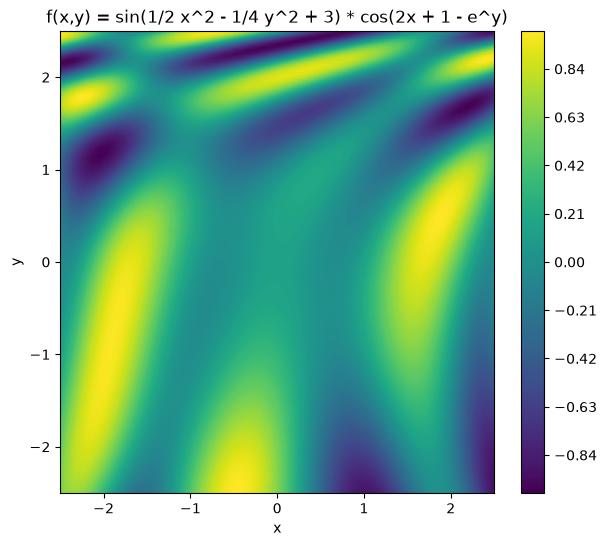

In [24]:
#Prepara los datos para dibujar el mapa de niveles de Z
resolucion = 150
rango = 2.5

X = np.linspace(-rango, rango, resolucion)
Y = np.linspace(-rango, rango, resolucion)
Z = np.zeros((resolucion, resolucion))
for ix, x in enumerate(X):
    for iy, y in enumerate(Y):
        Z[iy, ix] = f_reto([x, y])

plt.figure(figsize=(7,6))
plt.contourf(X, Y, Z, resolucion, cmap="viridis")
plt.colorbar()
plt.title("f(x,y) = sin(1/2 x^2 - 1/4 y^2 + 3) * cos(2x + 1 - e^y)")
plt.xlabel("x"); plt.ylabel("y")
plt.show()


In [25]:
random.seed(7)

N_REINICIOS   = 40     # multi-start: numero de puntos iniciales distintos
N_ITERACIONES = 300    # iteraciones de descenso por cada punto inicial
TA_INICIAL    = 0.08   # tasa de aprendizaje inicial

mejor_punto = None
mejor_valor = None
trayectorias = []   # guardamos todas las trayectorias para pintarlas

for reinicio in range(N_REINICIOS):
    P = [random.uniform(-rango, rango), random.uniform(-rango, rango)]
    traza = [tuple(P)]

    for it in range(N_ITERACIONES):
        grad = df_reto(P)
        # Tasa de aprendizaje decreciente -> mas estable cerca del minimo
        TA = TA_INICIAL / (1 + 0.02 * it)
        P = [P[0] - TA * grad[0], P[1] - TA * grad[1]]
        # Mantenemos el punto dentro del rango de estudio
        P[0] = min(max(P[0], -rango), rango)
        P[1] = min(max(P[1], -rango), rango)
        traza.append(tuple(P))

    valor_final = f_reto(P)
    trayectorias.append(traza)

    if mejor_valor is None or valor_final < mejor_valor:
        mejor_valor = valor_final
        mejor_punto = P

print("Mejor solucion encontrada tras", N_REINICIOS, "reinicios:")
print("  P =", mejor_punto)
print("  f(P) =", mejor_valor)


Mejor solucion encontrada tras 40 reinicios:
  P = [-2.0276506178267897, 1.1718268363569522]
  f(P) = -1.0


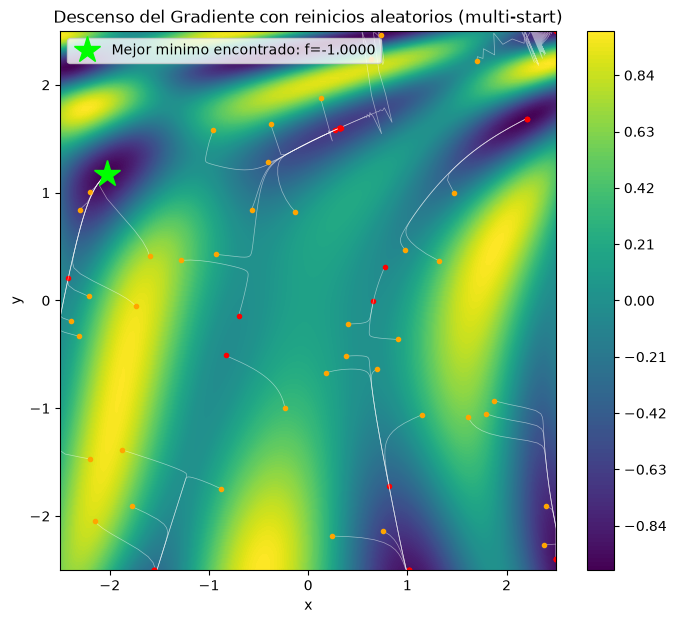

Solucion final -> x=-2.0277, y=1.1718, f(x,y)=-1.000000


In [26]:
#Dibujamos el mapa de niveles junto con todas las trayectorias de descenso
plt.figure(figsize=(8,7))
plt.contourf(X, Y, Z, resolucion, cmap="viridis")
plt.colorbar()

for traza in trayectorias:
    xs_t = [p[0] for p in traza]
    ys_t = [p[1] for p in traza]
    plt.plot(xs_t, ys_t, "-", c="white", linewidth=0.5, alpha=0.5)
    plt.plot(xs_t[0], ys_t[0], "o", c="orange", markersize=3)   # puntos iniciales
    plt.plot(xs_t[-1], ys_t[-1], "o", c="red", markersize=3)    # puntos finales

plt.plot(mejor_punto[0], mejor_punto[1], "*", c="lime", markersize=20,
          label=f"Mejor minimo encontrado: f={mejor_valor:.4f}")
plt.legend()
plt.title("Descenso del Gradiente con reinicios aleatorios (multi-start)")
plt.xlabel("x"); plt.ylabel("y")
plt.show()

print(f"Solucion final -> x={mejor_punto[0]:.4f}, y={mejor_punto[1]:.4f}, f(x,y)={mejor_valor:.6f}")


**Conclusión:** dado que la función es de la forma `sin(...) * cos(...)`, sus valores están acotados en `[-1, 1]`. El descenso del gradiente con reinicios aleatorios encuentra un valor muy próximo (o igual) a `-1`, es decir, un **mínimo global** de la función, lo que confirma que la estrategia de *multi-start* es apropiada para funciones no convexas como esta: un único punto de partida podría haber quedado atrapado en cualquiera de los muchos mínimos locales visibles en el mapa de niveles (las distintas "cuencas" azul oscuro).